# What do the SARS-Cov-2 genes do?


One process in the analysis of a new organism is annotating the genome. The first step of this analysis is to find potential genes through identifying open reading frames (ORFs). 
After this, the next question is which of these correspond to actual genes?

To answer this, we will lean on what we know about evolution. If two species are morphologically different, their genetic material must also differ substantially. Right? Not exactly. Evolution conserved many genes crucial for survival. The degree of conservation is surprising. For example, while we would expect to share many genes with the chimpanzee, our closest relative, we would expect almost no similarity in our genetic material with bananas. The numbers tell us otherwise. While sharing 96% of our genes with the chimpanzee, we also share 60% of our genes with bananas! These similar genes in humans and bananas encode proteins that carry similar functions.

Two genes with similar sequences may perform similar functions. Genes like these are called homologous genes. Or, more precisely, in our case, these would be orthologous genes (see the figure below). A pair of orthologous genes are genes from two related species originating from a common ancestor (e.g., humans and chimpanzees). Due to the evolution, the two nucleotide or protein sequences might differ slightly but not overwhelmingly.

<div>
<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/d/d8/Ortholog_paralog_analog_%28homologs%29.svg/1200px-Ortholog_paralog_analog_%28homologs%29.svg.png" width="500">
</div>

*Author: Thomas Shafee, Licence: CC BY 4.0*

The human-banana example demonstrates that these two organisms don't have to be that closely related! If we tried to determine the gene function in humans using bananas as a reference, we could infer the role of over 60% of the genes. However, using two closely related organisms would undoubtedly give us more robust results. We would be better off choosing the genome of a mouse or a chimpanzee as our reference.

Scientists have studied hundreds of viruses and determined the functions of most of their genes. Using viruses similar in sequence to SARS-Cov-2, we can characterize the SARS-CoV-2 ORFs to determine if they are the actual genes, and think about their function. Knowing what each gene does might help us find a way to fight the infection and potentially even find treatments for COVID-19. 

#### Please ensure each answer is completed in the single cell of the notebook immediately following the question, and that all answers are in ```markdown``` format.

Once you have completed the notebook, make sure you save it and submit it via Moodle.

All questions are worth between 4 and 10 marks. There are a total of *40 marks* available in this workbook. There is an extra bonus problem for *10 marks*. 
  
Total notebook marks will be scaled to a **course mark out of 10** to contribute to your course total.

In [1]:
from Bio import Entrez, SeqIO
from Bio.Align import substitution_matrices

In [2]:
# In order to import from the python file without hassle, we add the current
# directory to the python path
import sys; sys.path.append(".")

Let's let the nice folks at NCBI know who we are.

In [3]:
Entrez.email = "z5520141@ad.unsw.edu.au"

In [4]:
sars_record = SeqIO.read("data/sars_cov_2.fa", "fasta")

sars_spike_nt = sars_record.seq[21562:25384]
sars_spike_protein = str(sars_spike_nt.translate()).rstrip("*")

print(len(sars_spike_protein))
print(sars_spike_protein[:30])

1273
MFVFLVLLPLVSSQCVNLTTRTQLPPAYTN


## Finding SARS-CoV-2's closest relatives

In the first part of this assignment, we will analyze several coronavirus genomes to determine which are most similar to SARS-CoV-2. We will then use the viruses with the most similar sequence as reference genomes to assign functions to SARS-CoV-2 ORFs.

To find the closest reference genomes, we will align the SARS-CoV-2 sequence to each candidate coronavirus genome. The virus genomes with the highest alignment scores will be our most closely-related viruses.

Notice that computing an alignment between two sequences of length $N$ and $M$ requires the computation of a dynamic programming table with $N \cdot M$ entries. The size of this matrix is sufficiently small for short sequences. But even the short genomes, like viral genomes, are generally too long for this approach. Instead of computing similarities from the entire genomes, we will only focus on the spike protein sequence. In general, we would prefer to align the whole nucleotide sequences, but for this assignment, considering only a spike protein will be sufficient. The spike protein is also one of the essential parts of any coronavirus, as it is the one that grants the virus entry to host cells. 

Considering spike proteins alone reduces the sequence lengths from ~30k (entire virus) to around 1.3k (spike protein). Nevertheless, do your best to write fast, efficient Python code. Each `global_alignment` call on 1.3k long protein sequences should take around 30 to 60 seconds. 
We have to calculate 20 comparisons, which takes roughly 10 to 20 minutes.

In [5]:
accession_codes = {
    # 6 known human coronaviruses
    "Human-SARS": "NC_004718",
    "Human-MERS": "NC_019843",
    "Human-HCoV-OC43": "NC_006213",
    "Human-HCoV-229E": "NC_002645",
    "Human-HCoV-NL63": "NC_005831",
    "Human-HCoV-HKU1": "NC_006577",
    
    # Bat
    "Bat-CoV MOP1": "EU420138",
    "Bat-CoV HKU8": "NC_010438",
    "Bat-CoV HKU2": "NC_009988",
    "Bat-CoV HKU5": "NC_009020",
    "Bat-CoV RaTG13": "MN996532",
    "Bat-CoV-ENT": "NC_003045",
    
    # Other animals
    "Hedgehog-CoV 2012-174/GER/2012": "NC_039207",
    "Pangolin-CoV MP789": "MT121216",
    "Rabbit-CoV HKU14": "NC_017083",
    "Duck-CoV isolate DK/GD/27/2014": "NC_048214",
    "Feline infectious peritonitis virus": "NC_002306",  # cat
    "Giraffe-CoV US/OH3/2003": "EF424623",
    "Murine-CoV MHV/BHKR_lab/USA/icA59_L94P/2012": "KF268338",  # mouse
    "Equine-CoV Obihiro12-2": "LC061274",  # horse
}

In [ ]:
from Bio import Entrez, SeqIO
from Bio.Align import substitution_matrices

In [7]:
def get_spike_protein(accession):
    handle = Entrez.efetch(
        db="nuccore",
        id=accession,
        rettype="gb",
        retmode="text"
    )

    record = SeqIO.read(handle, "genbank")
    handle.close()

    for feature in record.features:
        if feature.type == "CDS":
            gene = feature.qualifiers.get("gene", [""])[0]
            product = feature.qualifiers.get("product", [""])[0]

            if gene.upper() == "S" or "spike" in product.lower():
                if "translation" in feature.qualifiers:
                    return feature.qualifiers["translation"][0]

    return None

In [8]:
spike_sequences = {}

for virus_name, accession in accession_codes.items():
    spike = get_spike_protein(accession)

    if spike is not None:
        spike_sequences[virus_name] = spike
        print(virus_name, len(spike))
    else:
        print("NO SPIKE FOUND:", virus_name)

Human-SARS 1255
Human-MERS 1353
Human-HCoV-OC43 1353
Human-HCoV-229E 1173
Human-HCoV-NL63 1356
Human-HCoV-HKU1 1356
Bat-CoV MOP1 1375
Bat-CoV HKU8 1375
Bat-CoV HKU2 1128
Bat-CoV HKU5 1352
Bat-CoV RaTG13 1269
Bat-CoV-ENT 1363
Hedgehog-CoV 2012-174/GER/2012 1330
Pangolin-CoV MP789 1265
Rabbit-CoV HKU14 1362
Duck-CoV isolate DK/GD/27/2014 1191
Feline infectious peritonitis virus 1452
Giraffe-CoV US/OH3/2003 1358
Murine-CoV MHV/BHKR_lab/USA/icA59_L94P/2012 1324
Equine-CoV Obihiro12-2 1363


Above is the list of coronaviruses and their corresponding NCBI accession codes that we will consider in this assignment. You can find the SARS-CoV-2 sequence in `data/sars_cov_2.fa`. This time, we will use the FASTA format to familiarize ourselves with the sequence file formats used in bioinformatics. You can easily read FASTA files using the `SeqIO.read` function from `biopython`.

We will only use part of the sequence, and to assess similarity, consider the spike protein alone. We will assume that we know the location of the spike protein in SARS-CoV-2 (strand=1, start=21562, stop=25384). We need to find a part of the sequence that encodes for the spike protein in all coronaviruses listed above. We can inspect each sequence's features to locate the spike protein. For this assignment, we will iterate through gene coding regions (CDS) for each coronavirus and find the one that codes for the "S" gene. Some coronaviruses do not include such annotation but instead report on a "spike protein" in the `product` field.

## Problem 1: Global alignment

**Task:** Use the template `global_alignment` function in the helper file to implement the Needleman-Wunsch algorithm for global sequence alignment. Use a "-" character for indels. Score the alignments using the BLOSUM62 substitution matrix. You can find it in `biopython`.

**[10 points]**

## Problem 2: Choosing our reference genomes

**Task:** Identify the three closest relatives to SARS-CoV-2. Use the `global_alignment` function you have just implemented, inspect their alignment scores, and select the three most similar sequences to our spike protein sequence. These will serve as reference genomes in Problem 4 of this assignment and help us determine the function of ORFs.

Save the full names of three coronaviruses with the closest matches to SARS-CoV-2's spike protein sequence as a Python list in the `three_closest_references` variable.

**[6 points]**

Then answer the following questions about global alignment and the three closest references.
- When aligning spike protein sequences with the global alignment, we used the BLOSUM62 substitution matrix by default. Examine the similarity of the protein alignments (the frequency of matching amino acids) and discuss whether it would be better to use the BLOSUM90 or BLOSUM45 substitution matrix in our case.
- The theory of evolution states that the SARS-CoV-2 virus must have evolved from some other virus in the past. Based on the three closest alignment references, is it more likely that SARS-CoV-2 jumped from another host organism or evolved from a human coronavirus? (We will explore this further in the following exercise.)

Store your answers in the `blosum_selection` and `viral_origin` variables, respectively.

**[4 points]**.

In [9]:
from helper_functions import global_alignment, scoring_function_blosum62

In [10]:
scores = {}

for virus_name, spike in spike_sequences.items():
    aligned1, aligned2, score = global_alignment(
        sars_spike_protein,
        spike,
        scoring_function_blosum62
    )

    scores[virus_name] = score

In [11]:
sorted_scores = sorted(
    scores.items(),
    key=lambda x: x[1],
    reverse=True
)

for virus_name, score in sorted_scores:
    print(virus_name, score)

Bat-CoV RaTG13 6539.0
Pangolin-CoV MP789 6085.0
Human-SARS 5246.0
Bat-CoV HKU5 1797.0
Human-MERS 1739.0
Murine-CoV MHV/BHKR_lab/USA/icA59_L94P/2012 1719.0
Hedgehog-CoV 2012-174/GER/2012 1694.0
Rabbit-CoV HKU14 1653.0
Bat-CoV-ENT 1629.0
Giraffe-CoV US/OH3/2003 1623.0
Human-HCoV-OC43 1617.0
Equine-CoV Obihiro12-2 1575.0
Human-HCoV-HKU1 1544.0
Human-HCoV-NL63 1158.0
Bat-CoV HKU8 1153.0
Feline infectious peritonitis virus 1150.0
Duck-CoV isolate DK/GD/27/2014 1124.0
Human-HCoV-229E 1101.0
Bat-CoV HKU2 1091.0
Bat-CoV MOP1 1087.0


In [12]:
computed_three_closest = [
    virus_name for virus_name, score in sorted_scores[:3]
]

print(computed_three_closest)

['Bat-CoV RaTG13', 'Pangolin-CoV MP789', 'Human-SARS']


In [13]:
three_closest_references = [
    "Bat-CoV RaTG13",
    "Pangolin-CoV MP789",
    "Human-SARS",
]

In [14]:
for virus_name in three_closest_references:
    spike = spike_sequences[virus_name]

    aligned_sars, aligned_ref, score = global_alignment(
        sars_spike_protein,
        spike,
        scoring_function_blosum62
    )

    matches = sum(
        a == b
        for a, b in zip(aligned_sars, aligned_ref)
        if a != "-" and b != "-"
    )

    aligned_positions = sum(
        a != "-" and b != "-"
        for a, b in zip(aligned_sars, aligned_ref)
    )

    identity = matches / aligned_positions * 100

    print(virus_name, round(identity, 2), "%")

Bat-CoV RaTG13 97.71 %
Pangolin-CoV MP789 91.13 %
Human-SARS 78.02 %


In [15]:
blosum_selection = """
Would it be better to use BLOSUM90 or BLOSUM45 substitution matrix in our case?

BLOSUM90 would be more suitable than BLOSUM45 in this case. The three closest
spike protein sequences have approximately 97.71%, 91.13%, and 78.02% amino
acid identity to SARS-CoV-2. BLOSUM90 is more appropriate for closely related
protein sequences, whereas BLOSUM45 is generally more suitable for more
distantly related sequences.
"""

In [16]:
viral_origin = """
Is it more likely that SARS-CoV-2 jumped from another host organism or evolved from a human coronavirus?

Based on the three closest references, SARS-CoV-2 is more likely to have
jumped from another host organism rather than evolved directly from a human
coronavirus. The two closest spike protein matches are Bat-CoV RaTG13 and
Pangolin-CoV MP789, while Human-SARS is the third closest match. This suggests
a closer relationship to coronaviruses from non-human hosts in this comparison.
"""

## MiniBLAST

A sophisticated approach for characterizing any genetic sequence is BLAST. BLAST stores a database of annotated genes (usually from various organisms) and then uses local alignment and heuristic search to find database genes with a similar sequence to a query one. Assuming that genes with similar protein sequences perform similar functions, we can infer the function of a query sequence by looking at the function of any matching genes returned by BLAST. It is also possible that BLAST will not find suitable matches, which may signal that a sequence might not be an actual gene or protein. In this problem, we will implement our simplified BLAST version and call it MiniBLAST. We will use MiniBLAST to determine whether each of our candidate ORFs is a gene. And if it is a gene, we will use the annotations to determine what the gene does.

Please note that BLAST is a complicated, optimized, heuristic, state-of-the-art technique to obtain very good approximate solutions. BLAST can query thousands of sequences in seconds. Our implementation will be slightly less sophisticated and somewhat more constrained but conceptually similar to that of BLAST.

## Problem 3: Local alignment

**Task:** Use the template `local_alignment` in the helper file and implement the Smith-Waterman algorithm for local sequence alignment.

**[10 points]**

In [17]:
from helper_functions import local_alignment

In [18]:
result = local_alignment(
    "pending itch",
    "unending glitch",
    lambda x, y: [-1, 1][x == y]
)

print(result)

('ending --itch', 'ending glitch', 9.0)


## Problem 4: Finding homologous genes

For this assignment, we have selected five promising SARS-CoV-2 ORFs. 

In [19]:
three_closest_references = [
    "Bat-CoV RaTG13",
    "Pangolin-CoV MP789",
    "Human-SARS",
]

print(three_closest_references)

['Bat-CoV RaTG13', 'Pangolin-CoV MP789', 'Human-SARS']


In [20]:
print(accession_codes)

{'Human-SARS': 'NC_004718', 'Human-MERS': 'NC_019843', 'Human-HCoV-OC43': 'NC_006213', 'Human-HCoV-229E': 'NC_002645', 'Human-HCoV-NL63': 'NC_005831', 'Human-HCoV-HKU1': 'NC_006577', 'Bat-CoV MOP1': 'EU420138', 'Bat-CoV HKU8': 'NC_010438', 'Bat-CoV HKU2': 'NC_009988', 'Bat-CoV HKU5': 'NC_009020', 'Bat-CoV RaTG13': 'MN996532', 'Bat-CoV-ENT': 'NC_003045', 'Hedgehog-CoV 2012-174/GER/2012': 'NC_039207', 'Pangolin-CoV MP789': 'MT121216', 'Rabbit-CoV HKU14': 'NC_017083', 'Duck-CoV isolate DK/GD/27/2014': 'NC_048214', 'Feline infectious peritonitis virus': 'NC_002306', 'Giraffe-CoV US/OH3/2003': 'EF424623', 'Murine-CoV MHV/BHKR_lab/USA/icA59_L94P/2012': 'KF268338', 'Equine-CoV Obihiro12-2': 'LC061274'}


In [21]:
reference_proteins = []

for virus_name in three_closest_references:
    accession = accession_codes[virus_name]

    handle = Entrez.efetch(
        db="nuccore",
        id=accession,
        rettype="gb",
        retmode="text"
    )

    record = SeqIO.read(handle, "genbank")
    handle.close()

    for feature in record.features:
        if feature.type == "CDS" and "translation" in feature.qualifiers:

            protein_seq = feature.qualifiers["translation"][0]

            gene_name = feature.qualifiers.get(
                "gene",
                feature.qualifiers.get("product", ["unknown"])
            )[0]

            product_name = feature.qualifiers.get(
                "product",
                ["unknown"]
            )[0]

            reference_proteins.append({
                "virus": virus_name,
                "gene": gene_name,
                "product": product_name,
                "protein": protein_seq
            })

print("Number of reference proteins:", len(reference_proteins))

Number of reference proteins: 36


In [22]:
for ref in reference_proteins:
    print(
        ref["virus"],
        "|",
        ref["gene"],
        "|",
        ref["product"],
        "|",
        len(ref["protein"])
    )

Bat-CoV RaTG13 | orf1ab | orf1ab polyprotein | 7095
Bat-CoV RaTG13 | S | spike glycoprotein | 1269
Bat-CoV RaTG13 | NS3 | nonstructural protein NS3 | 275
Bat-CoV RaTG13 | E | envelope protein | 75
Bat-CoV RaTG13 | M | membrane protein | 221
Bat-CoV RaTG13 | NS6 | nonstructural protein NS6 | 61
Bat-CoV RaTG13 | NS7a | nonstructural protein NS7a | 121
Bat-CoV RaTG13 | NS7b | nonstructural protein NS7b | 43
Bat-CoV RaTG13 | NS8 | nonstructural protein NS8 | 121
Bat-CoV RaTG13 | N | nucleocapsid protein | 419
Pangolin-CoV MP789 | orf1ab | orf1ab polyprotein | 7089
Pangolin-CoV MP789 | S | surface glycoprotein | 1265
Pangolin-CoV MP789 | ORF3 | ORF3 protein | 275
Pangolin-CoV MP789 | E | envelope protein | 75
Pangolin-CoV MP789 | M | membrane glycoprotein | 222
Pangolin-CoV MP789 | ORF6 | ORF6 protein | 61
Pangolin-CoV MP789 | ORF7a | ORF7a protein | 121
Pangolin-CoV MP789 | ORF7b | ORF7b protein | 43
Pangolin-CoV MP789 | ORF8 | ORF8 protein | 105
Pangolin-CoV MP789 | N | nucleocapsid phosp

In [23]:
orf_candidates = {
    "ORF-1": (1, 11995, 13483),
    "ORF-2": (1, 26792, 27191),
    "ORF-3": (1, 23650, 25384),
    "ORF-4": (-1, 421, 667),
    "ORF-5": (1, 9133, 13483),
}

In [24]:
orf_proteins = {}

for orf_name, (strand, start, stop) in orf_candidates.items():

    nt_seq = sars_record.seq[start:stop]

    if strand == -1:
        nt_seq = nt_seq.reverse_complement()

    protein = str(nt_seq.translate())

    if protein.endswith("*"):
        protein = protein[:-1]

    orf_proteins[orf_name] = protein

    print(orf_name, len(protein))

ORF-1 495
ORF-2 132
ORF-3 577
ORF-4 81
ORF-5 1449


We will now use MiniBLAST to compare these ORFs to known, annotated genes from the three closely-related coronaviruses you have stored in `three_closest_references`. The goal is to find the best matching gene from the reference genomes and decide if the quality of the match is sufficient to claim that ORF is an actual gene. 

Hint: among the five ORFs included in the candidates, we have planted one that is not a true gene.

**Task:** We start by building a reference database. For each of the three closely-related coronaviruses from Problem 2, extract the coding regions (CDS) from each genome, and convert them to protein sequences. Store the name of the virus each protein sequence came from and its function. In our case, the gene's function is evident from its name, e.g., "spike protein", "ORF1ab", and similar. Given `orf_candidates`, compute the local alignment to each protein sequence in our database. Inspect each alignment and its corresponding score, and decide whether the alignment is sufficiently good to assume they perform the same function.

Save your answers into the `orf_matches` variable as indicated in the cell below. Each ORF should be assigned a *closest-organism*, reporting the reference virus with the closest match, and a *homologous-gene*, indicating which gene the ORF matched to. If two ORFs match the reference with the same score, report one of them. For ORFs with no match in the reference, use None for both fields.

**[10 points]**

In [25]:
from helper_functions import local_alignment, scoring_function_blosum62

In [26]:
best_matches = {}

for orf_name, orf_protein in orf_proteins.items():
    best_score = float("-inf")
    best_match = None

    for ref in reference_proteins:
        aligned_orf, aligned_ref, score = local_alignment(
            orf_protein,
            ref["protein"],
            scoring_function_blosum62
        )

        if score > best_score:
            best_score = score
            best_match = {
                "virus": ref["virus"],
                "gene": ref["gene"],
                "product": ref["product"],
                "score": score,
                "aligned_orf": aligned_orf,
                "aligned_ref": aligned_ref
            }

    best_matches[orf_name] = best_match

In [27]:
for orf_name, match in best_matches.items():
    print(
        orf_name,
        "->",
        match["virus"],
        "|",
        match["gene"],
        "|",
        match["product"],
        "| score:",
        match["score"]
    )

ORF-1 -> Bat-CoV RaTG13 | orf1ab | orf1ab polyprotein | score: 2553.0
ORF-2 -> Bat-CoV RaTG13 | M | membrane protein | score: 678.0
ORF-3 -> Bat-CoV RaTG13 | S | spike glycoprotein | score: 2999.0
ORF-4 -> Human-SARS | ORF1ab | ORF1ab polyprotein | score: 61.0
ORF-5 -> Bat-CoV RaTG13 | orf1ab | orf1ab polyprotein | score: 7569.0


In [28]:
for orf_name, match in best_matches.items():
    a = match["aligned_orf"]
    b = match["aligned_ref"]

    matches = sum(
        x == y
        for x, y in zip(a, b)
        if x != "-" and y != "-"
    )

    aligned_positions = sum(
        x != "-" and y != "-"
        for x, y in zip(a, b)
    )

    identity = matches / aligned_positions * 100 if aligned_positions > 0 else 0

    print(
        orf_name,
        "|",
        match["virus"],
        "|",
        match["gene"],
        "| score =", match["score"],
        "| identity =", round(identity, 2),
        "| length =", aligned_positions
    )

ORF-1 | Bat-CoV RaTG13 | orf1ab | score = 2553.0 | identity = 100.0 | length = 491
ORF-2 | Bat-CoV RaTG13 | M | score = 678.0 | identity = 100.0 | length = 132
ORF-3 | Bat-CoV RaTG13 | S | score = 2999.0 | identity = 99.65 | length = 577
ORF-4 | Human-SARS | ORF1ab | score = 61.0 | identity = 23.94 | length = 71
ORF-5 | Bat-CoV RaTG13 | orf1ab | score = 7569.0 | identity = 99.65 | length = 1445


In [29]:
orf_matches = {
    "ORF-1": {
        "closest-organism": "Bat-CoV RaTG13",
        "homologous-gene": "orf1ab",
    },
    "ORF-2": {
        "closest-organism": "Bat-CoV RaTG13",
        "homologous-gene": "M",
    },
    "ORF-3": {
        "closest-organism": "Bat-CoV RaTG13",
        "homologous-gene": "S",
    },
    "ORF-4": {
        "closest-organism": None,
        "homologous-gene": None,
    },
    "ORF-5": {
        "closest-organism": "Bat-CoV RaTG13",
        "homologous-gene": "orf1ab",
    },
}

## Bonus Problem: Repurposing SARS-CoV drug treatments for SARS-CoV-2

You might have noticed that the coronavirus we've been working with ends with the number 2. That means there must have been a SARS-CoV-1 at some point, right? Indeed there was. The SARS-CoV-1 virus caused a SARS outbreak in 2002-2004 and infected over 8,000 people from 29 countries, killing at least 774 people. These may seem like small numbers today, but at the time, the outbreak caused much panic because the virus had a much higher mortality rate than SARS-CoV-2. 

Several drugs were developed and tested for the treatment of SARS. Some proved effective. Since SARS-CoV-2 is closely related to SARS-CoV-1, we could repurpose some effective drugs for SARS-CoV-1. We will look at one drug in particular: EK1 binds to a specific region on the SARS-CoV-1 spike protein and prevents the virus from entering the cells, thus stopping the infection and, consequently, the spread of the virus. Assuming the spike protein in SARS-CoV-2 is similar enough to the spike protein in SARS-CoV-1, EK1 may be able to bind to the SARS-CoV-2 spike protein and subsequently stop the infection.

EK1 recognizes a specific sequence (or motif) of aminoacid types: **_hpphcpc_** where **_h_** is a hydrophobic, **_p_** is a polar, and **_c_** is a charged amino acid. There are approximately six consecutive repeats of this motif in SARS-CoV-1, so we expect to find a similar pattern in the SARS-CoV-2 spike protein. The individual amino acid types in this motif are not equally important for the successful binding of EK1. For instance, it is much more important for the **_h_** amino acids to be in the correct spots than the **_p_** or **_c_** amino acids. It is also critical that none of the amino acids are missing in the spike protein, as this will prevent binding.

Aminoacids and their corresponding types (**_h_**, **_p_**, or **_c_**) are provided in `data/aminoacid_properties.csv`.

**Task:** Determine whether EK1 can bind to the SARS-CoV-2 spike protein. Based on the description of how EK1 binds to the spike protein in the paragraphs above, design a scoring function that will appropriately weigh amino acid matches/mismatches. Then, perform local alignment between the SARS-CoV-1 spike protein sequence and the EK1 target motif (**_hpphcpc_** repeated six times). Since EK1 was developed for SARS-CoV-1, we know there should be a valid binding motif somewhere along the SARS-CoV-1 spike protein. Use this fact to calibrate your scoring function. Can we find an EK1 binding motif in the SARS-CoV-2 spike protein? Plot the positions of the best alignments in both viruses. For each virus, plot a horizontal line representing the spike protein sequence and a bar indicating the location of the EK1 binding motif. Ensure the two genomes are aligned to see whether the binding motifs appear in the same general regions of the spike protein. Save your figure into `problem-bonus.png`.

**[5 points]**

Then answer the following questions:
- Does the SARS-CoV-2 spike protein contain the EK1 binding motif?
- Are SARS-CoV-1 and SARS-CoV-2 motifs comparable? What procentage of the aminoacids match between the motifs?
- Since the introduction of EK1 as a potential COVID-19 treatment, the drug has seen further development. Does the treatment work on COVID-19 patients? Search through literature and provide at least two references.

Store your answers in the `binding_motif_present`, `binding_motif_similarity` and `EK1_drug_efficacy` variables, respectively.

**[5 points]**

*Hint*: Our task is to design a scoring function that reflects the underlying process of binding EK1 to the spike protein. For instance, since no amino acids must be missing from the spike protein sequence, we can design our scoring function to disallow any indels in our alignment. We can achieve this by heavily penalizing indels. Similarly, if we know hydrophobic matches are more important than polar or charged matches, we can appropriately weigh matches and penalize mismatches between these types of proteins.



In [30]:
import csv

aa_properties = {}

with open("data/aminoacid_properties.csv") as f:
    reader = csv.DictReader(f)

    for row in reader:
        aa = row["aminoacid"]

        aa_properties[aa] = {
            "hydrophobicity": float(row["hydrophobicity"]),
            "type": row["polarity"]
        }


In [31]:
ek1_motif = "hpphcpc" * 6

print(ek1_motif)
print(len(ek1_motif))

hpphcpchpphcpchpphcpchpphcpchpphcpchpphcpc
42


In [32]:
sars1_spike = spike_sequences["Human-SARS"]
sars2_spike = sars_spike_protein

print(len(sars1_spike))
print(len(sars2_spike))

1255
1273


In [33]:
def ek1_scoring(aa, motif_type):
    if aa == "-" or motif_type == "-":
        return -1000

    aa_type = aa_properties[aa]["type"]

    if motif_type == "h":
        return 5 if aa_type == "h" else -5
    elif motif_type == "p":
        return 2 if aa_type == "p" else -2
    elif motif_type == "c":
        return 2 if aa_type == "c" else -2

In [34]:
from helper_functions import local_alignment

sars1_result = local_alignment(
    sars1_spike,
    ek1_motif,
    ek1_scoring
)

sars2_result = local_alignment(
    sars2_spike,
    ek1_motif,
    ek1_scoring
)

print("SARS-CoV-1:")
print(sars1_result)

print("\nSARS-CoV-2:")
print(sars2_result)

SARS-CoV-1:
('AQALNTLVKQLSSNFGAISSVLNDILSRLDKVEAEVQ', 'hpphcpchpphcpchpphcpchpphcpchpphcpchp', 47.0)

SARS-CoV-2:
('AQALNTLVKQLSSNFGAISSVLNDILSRLDKVEAEVQ', 'hpphcpchpphcpchpphcpchpphcpchpphcpchp', 47.0)


In [35]:
sars1_best = sars1_result[0].replace("-", "")
sars2_best = sars2_result[0].replace("-", "")

sars1_start = sars1_spike.find(sars1_best)
sars2_start = sars2_spike.find(sars2_best)

sars1_end = sars1_start + len(sars1_best)
sars2_end = sars2_start + len(sars2_best)

matches = sum(
    a == b
    for a, b in zip(sars1_best, sars2_best)
)

similarity = matches / len(sars1_best) * 100

print("SARS-CoV-1:", sars1_start, "-", sars1_end)
print("SARS-CoV-2:", sars2_start, "-", sars2_end)
print("Aligned motif length:", len(sars1_best))
print("Similarity:", similarity, "%")

SARS-CoV-1: 937 - 974
SARS-CoV-2: 955 - 992
Aligned motif length: 37
Similarity: 100.0 %


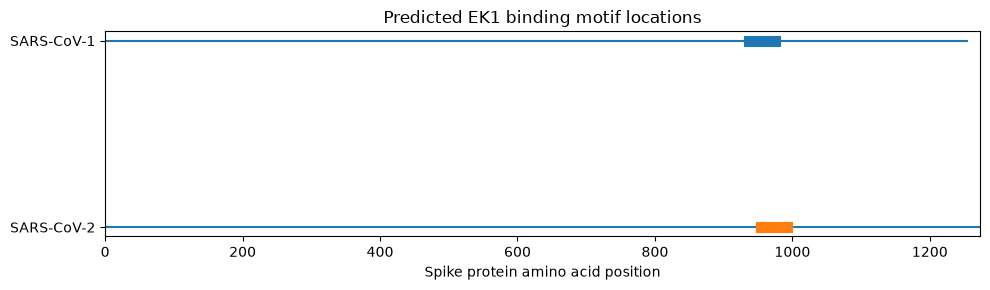

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 3))

# full spike proteins
plt.hlines(1, 0, len(sars1_spike))
plt.hlines(0, 0, len(sars2_spike))

# EK1 binding regions
plt.plot(
    [sars1_start, sars1_end],
    [1, 1],
    linewidth=8
)

plt.plot(
    [sars2_start, sars2_end],
    [0, 0],
    linewidth=8
)

plt.yticks(
    [1, 0],
    ["SARS-CoV-1", "SARS-CoV-2"]
)

plt.xlim(0, max(len(sars1_spike), len(sars2_spike)))
plt.xlabel("Spike protein amino acid position")
plt.title("Predicted EK1 binding motif locations")

plt.tight_layout()
plt.savefig("problem-bonus.png", dpi=300)
plt.show()

In [37]:
binding_motif_present = """
Yes. Based on the scoring scheme and local alignment, SARS-CoV-2 contains a
high-scoring predicted EK1 binding region. The best local alignment spans
37 amino acids and corresponds to the predicted EK1-binding region found in
SARS-CoV-1.
"""

In [38]:
binding_motif_similarity = """
Yes. The predicted EK1-binding regions in SARS-CoV-1 and SARS-CoV-2 are highly
comparable. The best local alignments span 37 amino acids, and the aligned
amino acid sequences are identical, giving 100% amino acid identity.
"""

In [39]:
EK1_drug_efficacy = """
EK1 and its derivatives show promising activity against SARS-CoV-2, but the
evidence reported in these studies is preclinical rather than evidence of
established efficacy in COVID-19 patients. Xia et al. (2020) showed that EK1
inhibited SARS-CoV-2 spike-mediated membrane fusion, while the derivative
EK1C4 showed substantially stronger antiviral activity. Xia et al. (2021)
further showed antiviral activity of EK1 and EK1C4 in cell culture and found
that intranasal EK1 reduced viral titers in hACE2-transgenic mice. Therefore,
EK1 has strong experimental support as a potential SARS-CoV-2 fusion inhibitor,
but these studies do not demonstrate confirmed therapeutic efficacy in human
COVID-19 patients.

References:
Xia et al. (2020). Inhibition of SARS-CoV-2 infection by a highly potent
pan-coronavirus fusion inhibitor targeting its spike protein.
Cell Research, 30, 343-355.

Xia et al. (2021). Structural and functional basis for pan-CoV fusion
inhibitors against SARS-CoV-2 and its variants with preclinical evaluation.
Signal Transduction and Targeted Therapy, 6, 288.
"""